# Neural machine translation through transformer

Welcome to the last HDA laboratory! In this notebook, you will implement a Transformer for sentence translation from Portuguese to English. The Transformer was originally proposed in ["Attention is all you need"](https://arxiv.org/abs/1706.03762) by Vaswani et al. (2017) and is a sequence-to-sequence encoder-decoder architecture similar to the model seen in Laboratory 7.
This notebook is a revisitation of the one proposed by [TensorFlow](https://www.tensorflow.org/text/tutorials/transformer).

**In this assignment, you will:**
- Implement the basic building blocks of the positional embedding, attention layer, encoder and a decoder for a Transformer model.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd '/content/drive/MyDrive/MLHD_labs/Lab_transformers'

/content/drive/MyDrive/MLHD_labs/Lab_transformers


A single-layer Transformer takes a little more code to write, but is similar to the encoder-decoder RNN model you saw in Lab 6. The difference is that the RNN layers are replaced with self attention layers.
In this notebook you will build a 4-layer Transformer which is larger and more powerful than a single-layer one, but not fundamentally more complex.

<table>
<tr>
  <th>A RNN+Attention model (Lab 6)</a></th>
  <th>A 1-layer transformer</th>
  <th>A 4-layer Transformer</th>
</tr>
<tr>
  <td>
   <img width=380 src="https://www.tensorflow.org/images/tutorials/transformer/RNN+attention-words.png"/>
  </td>
  <td>
   <img width=380 src="https://www.tensorflow.org/images/tutorials/transformer/Transformer-1layer-words.png"/>
  </td>
  <td>
   <img width=318 src="https://www.tensorflow.org/images/tutorials/transformer/Transformer-4layer-compact.png"/>
  </td>
</tr>
</table>

The neural network architecture used to implement each layer of the Transformer is depicted in the figure below. In this notebook you will implement all the components.

<center><img width=400 src="https://www.tensorflow.org/images/tutorials/transformer/transformer.png"/></center>

After training the model in this notebook, you will be able to input to the model a Portuguese sentence and obtain as output the English translation. Some examples of the attention weights generated by the Transformer model are displayed in the figure below. At the end of the notebook you will be able to obtain your own maps.

<center><img src="https://www.tensorflow.org/images/tutorials/transformer/attention_map_portuguese.png" alt="Attention heatmap"></center>


## Install and import statements

In [3]:
# You can run this just the first time
!pip install -q -U tensorflow-text tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 86.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.18.0 which is incompatible.


In [4]:
import logging
import time

import numpy as np
import matplotlib.pyplot as plt

import tensorflow_datasets as tfds
import tensorflow as tf

import tensorflow_text

from utils import get_tokenizers, positional_encoding, masked_loss, masked_accuracy

## Dataset load

Use TensorFlow Datasets to load the [Portuguese-English translation dataset](https://www.tensorflow.org/datasets/catalog/ted_hrlr_translate#ted_hrlr_translatept_to_en) from the TED Talks Open Translation Project. This dataset contains approximately 52,000 training, 1,200 validation and 1,800 test examples.

In [5]:
examples, metadata = tfds.load('ted_hrlr_translate/pt_to_en',
                               with_info=True,
                               as_supervised=True)

train_dataset, val_dataset = examples['train'], examples['validation']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/51785 [00:00<?, ? examples/s]

...

Generating validation examples...:   0%|          | 0/1193 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/incomplete.7G5B53_1.0.0/ted_hrlr_translate-val…

Generating test examples...:   0%|          | 0/1803 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/incomplete.7G5B53_1.0.0/ted_hrlr_translate-tes…

Dataset ted_hrlr_translate downloaded and prepared to /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/1.0.0. Subsequent calls will reuse this data.


The `tf.data.Dataset` object returned by TensorFlow Datasets yields pairs of text examples. Visualize some examples by executing the code cell below.

In [6]:
for pt_examples, en_examples in train_dataset.batch(3).take(1):
  print('> Examples of Portuguese sentences:')
  for pt in pt_examples.numpy():
    print(pt.decode('utf-8'))
  print()

  print('> Examples of English sentences:')
  for en in en_examples.numpy():
    print(en.decode('utf-8'))

> Examples of Portuguese sentences:
e quando melhoramos a procura , tiramos a única vantagem da impressão , que é a serendipidade .
mas e se estes fatores fossem ativos ?
mas eles não tinham a curiosidade de me testar .

> Examples of English sentences:
and when you improve searchability , you actually take away the one advantage of print , which is serendipity .
but what if it were active ?
but they did n't test for curiosity .


## 1 - Sentence tokenization

As done in Lab 6, the first thing to do is to tokenize the text, so that each element is encoded (represented) as a token or token ID, i.e., a numeric representation.

Depending on the tokenization strategy, the **tokens can represent sentence-pieces, words, subwords, or characters.**
In Laboratory 6 we used a very simple tokenizer where each token represented a single word (see the class `Encoder` in Lab 6).

In this Laboratory we will use a more advanced tokenization strategy known as **subword (or wordpiece) tokenization**.
In wordpiece tokenization, a single word is encoded through a single token or multiple tokens. A subword consists of a root word, a prefix, or a suffix. For example, a language model that uses subwords as tokens might view the word "dogs" as two tokens (the root word "dog" and the plural suffix "s"), and the word "taller" as two subwords (the root word "tall" and the suffix "er").

In order to perform wordpiece tokenization, we will leverage a `text.BertTokenizer` Tensorflow object that is already optimized for the specific datasets we will use. The `tokenize` method of `text.BertTokenizer` objects converts a batch of strings into a Ragged Tensor of token IDs (i.e., a tensor with non uniform shapes). This method splits punctuation, lowercases and unicode-normalizes the input before tokenizing. For more details about setting up this kind of tokenizers from scratch, please see [here](https://www.tensorflow.org/text/guide/subwords_tokenizer?hl=en).

In this Laboratory, you will directly download, extract, and import the tokenizers for the english and portoguese sentences from the Tensorflow servers, by using the `get_tokenizers` utility function implemented in the `utils.py` file in the Lab's folder.

In [7]:
tokenizer_en, tokenizer_pt = get_tokenizers()

To visualize an example, try to tokenize the `en_examples` that you extracted before from the dataset. You need to apply the method `tokenize` to the `tokenize_en` object.

In [8]:
encoded = tokenizer_en.tokenize(en_examples)

print('This is the text split into tokens IDs:\n')
for row in encoded.to_list():
  print(row)

This is the text split into tokens IDs:

[2, 72, 117, 79, 1259, 1491, 2362, 13, 79, 150, 184, 311, 71, 103, 2308, 74, 2679, 13, 148, 80, 55, 4840, 1434, 2423, 540, 15, 3]
[2, 87, 90, 107, 76, 129, 1852, 30, 3]
[2, 87, 83, 149, 50, 9, 56, 664, 85, 2512, 15, 3]


To obtain the value of the tokens (i.e., the word or subword) associated with the token IDs above, you can use the `lookup` method after applying the `tokenize` method, as displayed in the code cell below.

In [9]:
print('This is the text split into tokens:\n')
tokens = tokenizer_en.lookup(encoded)
print(tokens)

This is the text split into tokens:

<tf.RaggedTensor [[b'[START]', b'and', b'when', b'you', b'improve', b'search', b'##ability',
  b',', b'you', b'actually', b'take', b'away', b'the', b'one', b'advantage',
  b'of', b'print', b',', b'which', b'is', b's', b'##ere', b'##nd', b'##ip',
  b'##ity', b'.', b'[END]']                                                 ,
 [b'[START]', b'but', b'what', b'if', b'it', b'were', b'active', b'?',
  b'[END]']                                                           ,
 [b'[START]', b'but', b'they', b'did', b'n', b"'", b't', b'test', b'for',
  b'curiosity', b'.', b'[END]']                                          ]>


The output show the "subword" aspect of the subword tokenization.

For example, the word `'searchability'` is decomposed into `'search'` and `'##ability'`, and the word `'serendipity'` into `'s'`, `'##ere'`, `'##nd'`, `'##ip'` and `'##ity'`.

Note that the tokenized text includes `'[START]'` and `'[END]'` tokens.

### Prepare the data load pipeline with `tf.data`

We need to define a function (`prepare_batch`) that takes the pairs of English and Portuguese sentences for training and converts them into a format that can be used as `input`s and `label`s for the neural network model, as depicted in the figure below.


<center><img width=400 src="https://www.tensorflow.org/images/tutorials/transformer/Transformer-1layer-words.png"/></center>
<caption><center> <u> Figure 1 </u>: The inputs of the model are at the bottom while the labels are at the top.</center></caption>


Remember that the Tensoflow `Model.fit` function expects `(inputs, labels)` pairs.
The `inputs` will be pairs of tokenized Portuguese and English sequences, `(pt, en)`.
The `labels` will be the same English sequences shifted by 1, so that at each input location the `label` is the id of the next token. This setup is called "teacher forcing" (the same that you saw in Laboratory 6) because regardless of the model's output at each timestep, it gets the true value as input for the next timestep.
This is a simple and efficient way to train a text generation model.
It's efficient because you don't need to run the model sequentially, the outputs at the different sequence locations can be computed in parallel.

The `prepare_batch` function will be applied to the `tf.Data.dataset`s `train_dataset` and `val_dataset` that you loaded before through the `map` method. The function should consist of five steps:

1. Tokenize the text (both English and Portuguese);
2. Trim the sequences of tokens to be no longer than `MAX_TOKENS`;
3. Split the target (English) tokens into inputs and labels. Each label sentence is obtained by shifting a input sentence by one step;
4. Convert the ragged Tensors to padded dense Tensors (this is required because the sentences may have different lengths but we need fixed input length for the Tensorflow model);
5. Return `(input, labels)` pairs.

In [10]:
MAX_TOKENS=128

def prepare_batch(pt, en):
    """
    This function takes batches of text, and outputs the inputs (pt, en_inputs)
    and labels (en_labels) for training the transformer

    :param pt: Batch of portoguese sentences
    :param en: Batch of english sentences
    """

    ## PORTUGUESE ##
    # 1. Tokenize the sentences
    pt = tokenizer_pt.tokenize(pt)
    # 2. Trim the sequences to be no longer than MAX_TOKENS
    pt = pt[:, :MAX_TOKENS]
    # 4. Convert the Ragged Tensors to dense Tensors
    pt = pt.to_tensor()

    ## ENGLISH ##
    # 1. Tokenize the sentences
    en = tokenizer_en.tokenize(en)

    # 2. Trim the sequences to be no longer than MAX_TOKENS+1
    en = en[:, :(MAX_TOKENS+1)]

    # 3. Split the target sequence (English) into inputs and labels
    # Inputs: en from 0 to -1, i.e., drop the [END] tokens
    en_inputs = en[:, :-1]
    # Labels: en from 1 until the end, i.e., drop the [START] tokens
    en_labels = en[:, 1:]

    # 4. Convert the Ragged Tensors to dense Tensors
    en_inputs = tf.cast(en_inputs.to_tensor(), dtype=tf.int64)
    en_labels = tf.cast(en_labels.to_tensor(), dtype=tf.int64)

    # 5. Return (input, labels) pair
    # (remember that the input is itself a pair of pt and en tokens)
    return (pt, en_inputs), en_labels

At this point we can define the complete pipeline to process the input `train_dataset` and `val_dataset` `tf.Data.dataset`. The pipeline consists of four steps:

1. Use the `shuffle` method to shuffle the dataset during training;
2. Use the `batch` method to group the data into batches of equal size;
3. Use the `map` method to apply the `prepare_batch` function, in order to correctly tokenize and pad the sequences;
4. Use `prefetch` method to run the dataset in parallel with the model to ensure that data is available when needed. The number of elements to prefetch should be equal to (or possibly greater than) the number of batches consumed by a single training step. You could either manually tune this value, or set it to `tf.data.AUTOTUNE`, which will prompt the `tf.data` runtime to tune the value dynamically at runtime.

We already saw this process several times (Lab 3, Lab 5, Lab 6), if you have some doubt take a look at the [documentation here](https://www.tensorflow.org/guide/data_performance)

In [11]:
BUFFER_SIZE = 20000
BATCH_SIZE = 64

In [12]:
def make_batches(ds):
    # 1. Shuffle the dataset
    ds = ds.shuffle(BUFFER_SIZE)

    # 2. Batch the dataset
    ds = ds.batch(BATCH_SIZE)

    # 3. Map the prepare_batch function to each batch
    ds = ds.map(prepare_batch, tf.data.AUTOTUNE)

    # 4. Prefetch the dataset
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    return ds

To check if you coded correctly the `make_batches` function, try to apply it to the `train_dataset` and `val_dataset`.

In [13]:
# Create training and validation set batches.
train_batches = make_batches(train_dataset)
val_batches = make_batches(val_dataset)

Print the size of the elements in the first batch.

In [14]:
for (pt, en), en_labels in train_batches.take(1):
  break

print(pt.shape)
print(en.shape)
print(en_labels.shape)

(64, 82)
(64, 67)
(64, 67)


Visualize the `en` and `en_labels`. As mentioned above they are the same, just shifted by 1.

In [15]:
print(en[0][:10])
print(en_labels[0][:10])

tf.Tensor([  2  96  80 121 296  95  90   9  55 131], shape=(10,), dtype=int64)
tf.Tensor([ 96  80 121 296  95  90   9  55 131  92], shape=(10,), dtype=int64)


## 2 - Embedding and positional encoding layer

Here you will write the code for the first step of processing of the inputs. The inputs to both the encoder and decoder use the same embedding and positional encoding logic.

<center><img src="https://www.tensorflow.org/images/tutorials/transformer/PositionalEmbedding.png"/></center>

**Embedding:** At first, both the input tokens (Portuguese) and target tokens (English) have to be converted to vectors using a `tf.keras.layers.Embedding` layer.

**Positional encoding:** The attention layers that is used throughout the Transformer model see their input as a set of vectors, with no order. Hence, we need some way to identify word order, otherwise it would see the input sequence as a [bag of words](https://developers.google.com/machine-learning/glossary#bag-of-words), e.g., `how are you`, `how you are`, `you how are`. To do that, the Transformer adds a "Positional Encoding" to the embedding vectors. The encoding uses a set of sines and cosines at different frequencies (that change across the sequence). By definition nearby elements will have similar position encodings.
Specifically, the original Transformer's paper uses the following formula for calculating the positional encoding:

$$\Large{PE_{(pos, 2i)} = \sin(pos / 10000^{2i / d_{model}})} $$
$$\Large{PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i / d_{model}})} $$

\\
You will now implement a `PositionEmbedding` layer that looks-up a token's embedding vector and adds the position vector to it. For this laboratory, the positional encoding is already coded for you in the `positional_encoding` function (inside `utils.py`).

The `compute_mask` method is needed to inform the model that some part of the data is actually padding and should be ignored, see the [documentation here](https://www.tensorflow.org/guide/keras/understanding_masking_and_padding#masking). The mask is propagated through the network to keep track of the meaningful portion of data at each layer [see here](https://www.tensorflow.org/guide/keras/understanding_masking_and_padding#mask_propagation_in_the_functional_api_and_sequential_api). The `compute_mask` is a method already defined by the `tf.keras.layers.Embedding`, here we want that the `PositionalEmbedding` layer, that we create, return the mask in the same way. To enable the mask you should use `mask_zero=True` when creating the `tf.keras.layers.Embedding` layer.

In [16]:
class PositionalEmbedding(tf.keras.layers.Layer):
  def __init__(self, vocab_size, key_dim):
    super().__init__()
    self.key_dim = key_dim
    self.embedding = tf.keras.layers.Embedding(vocab_size, key_dim, mask_zero=True)
    self.pos_encoding = positional_encoding(length=2048, depth=key_dim)

  def compute_mask(self, *args, **kwargs):
    return self.embedding.compute_mask(*args, **kwargs)

  def call(self, x):
    length = tf.shape(x)[1]
    x = tf.cast(x, dtype=tf.int64)
    x = self.embedding(x)
    # This factor sets the relative scale of the embedding and positonal_encoding.
    x *= tf.math.sqrt(tf.cast(self.key_dim, tf.float32))
    pos_enc = self.pos_encoding[tf.newaxis, :length, :]
    x = x + pos_enc
    return x

Test the code you wrote by creating two `PositionalEmbedding` layers, one for Portuguese sentences and one for the English sentences. Pass `pt` and `en` that you extracted above from the examples of train batching as input for the layers and print the mask. The vocabulary size can be obtained through the `get_vocab_size()` method of `tokenizer_pt` and `tokenizer_pt`. You can try `key_dim=512`.

In [17]:
#tf.keras.config.disable_traceback_filtering()

In [18]:
embed_pt = PositionalEmbedding(vocab_size=tokenizer_pt.get_vocab_size().numpy(), key_dim=512)
embed_en = PositionalEmbedding(vocab_size=tokenizer_en.get_vocab_size().numpy(), key_dim=512)

pt_emb = embed_pt(pt)
en_emb = embed_en(en)

# The _keras_mask member variable is the returned value from the compute_mask method
en_emb._keras_mask

<tf.Tensor: shape=(64, 67), dtype=bool, numpy=
array([[ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       ...,
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False]])>

## 3 - Building blocks: Add and normalize layer

The "Add & Norm" blocks are scattered throughout the Transformer model. Each one joins the output of a Feed forward layer and a residual connection and process the result through a `LayerNormalization` layer.

The residual "Add & Norm" blocks are included for training efficiency. The residual connection provides a direct path for the gradient (and ensures that input vectors are **updated** by the attention layers instead of **replaced**), while the normalization maintains a reasonable scale for the outputs.

Note: The implementations, below, use the `Add` layer to ensure that Keras masks are propagated (the `+` operator does not).


<center><img src="https://www.tensorflow.org/images/tutorials/transformer/Add+Norm.png"/></center>

The "Add & Norm" layer is used as part of:

1. The **Attention Layers** (3 types)
2. The **Feed Forward Networks**

In the following you will implement the different blocks separately.

## 4 - Building blocks: The Attention Layers

The Transformer model extensively makes use of the attention mechanism.
The attention operation is applied on different sets of queries/keys/values depending on the position of the layer in the network architecture. Take a look at the Attention refresher inside the Tensorflow tutorial [at this link](https://www.tensorflow.org/text/tutorials/transformer#attention_refresher).


The Transformer model implements three different types of Attention Layers:
1. **Global Self Attention**: used in the Encoder Layers of the model, attends information from the whole input sequence.
2. **Causal Self Attention**: used in the first part of the Decoder Layers, attends information from the target sequence, in a causal way (i.e., can't attend information from future tokens).
3. **Cross Attention**: used in the second part of the Decoder Layers, attends information both from the Decoder and Encoder.

These three types of layers share a similar structure. In turn, in this laboratory we will make use of class inheritance so that we can avoid writing the same code multiple times: you will first create a `BaseAttention` layer defining the general features that all the attention layers have in common and inherit from the `BaseAttention` layer; hence you will implement the three specialized layers.

In the diagram below, you can see how the classes will be organized, and also where each type of attention will be used in the model architecture.
<center>
<img src="https://drive.google.com/uc?export=view&id=13KR20J3SzRAjQ49phGHX1KSLZm7jLYWk"/>
</center>







### 4a - The base attention layer

We start with the `BaseAttention` class that just contains the component layers that all the three types of attention share: a [`layers.MultiHeadAttention`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MultiHeadAttention) layer, a `layers.Add` layer for the residual connection, and finally a `layers.LayerNormalization` layer.

The three types of Attention layers will be implemented as subclasses of this `BaseAttention` layer.

In [19]:
class BaseAttention(tf.keras.layers.Layer):
  def __init__(self, **kwargs):
    super().__init__()
    self.mha = tf.keras.layers.MultiHeadAttention(**kwargs)
    self.layernorm = tf.keras.layers.LayerNormalization()
    self.add = tf.keras.layers.Add()

### 4b - The cross attention layer

The core of the Transformer is the cross-attention layer that connects the encoder and decoder.

To implement this layer, you pass the target sequence `x` as the `query` and the `context` sequence as the `key/value` when calling the `MultiHeadAttention` layer. Use `return_attention_scores=True`. Note that the constructor of `CrossAttention` is inherited from the `BaseAttention` class, here you have to implement the `call` method that is used during input forwarding. This applies to all the three attention layers you will implement in this notebook.

In [20]:
class CrossAttention(BaseAttention):
  def call(self, x, context):
    attn_output, attn_scores = self.mha(
        query=x,
        key=context,
        value=context,
        return_attention_scores=True)

    # Cache the attention scores for plotting later.
    self.last_attn_scores = attn_scores

    x = self.add([x, attn_output])
    x = self.layernorm(x)

    return x

To test the `CrossAttention` layer, use it to process a sample input (use the `pt_emb` and `en_emb` you obtained in Section 2 of this notebook). To instantiate a `CrossAttention` layer you need to pass the arguments needed for the [`MultiHeadAttention` layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MultiHeadAttention), i.e., as `**kwargs` you need to specify at least `num_heads` (number of attention heads) and `key_dim` (size of each attention head for query and key).

In [21]:
sample_ca = CrossAttention(num_heads=2, key_dim=512)

print(pt_emb.shape)
print(en_emb.shape)
print(sample_ca(en_emb, pt_emb).shape)

(64, 82, 512)
(64, 67, 512)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'query' (of type EinsumDense) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'key' (of type EinsumDense) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'value' (of type EinsumDense) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


(64, 67, 512)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'cross_attention' (of type CrossAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


### 4c - The global self attention layer

This layer is responsible for processing the context sequence, and propagating information along its length. Since the context sequence is fixed while the translation is being generated, information is allowed to flow in both directions.

Before Transformers and self attention, models commonly used RNNs or CNNs to do this task (as done in Lab 6). Remarkably, the global self attention layer lets every sequence element directly access every other sequence element, with only a few operations, and all the outputs can be computed in parallel. This allows for extremely faster processing in modern GPUs.

To implement this layer you just need to pass the target sequence, `x`, as both the `query`, and `key/value` arguments to the `mha` layer in the `call` method.

In [22]:
class GlobalSelfAttention(BaseAttention):
  def call(self, x):
    attn_output = self.mha(
        query=x,
        value=x,
        key=x)
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    return x

Test the `GlobalSelfAttention` as done before for the `CrossAttention` layer.

In [23]:
sample_gsa = GlobalSelfAttention(num_heads=2, key_dim=512)

print(pt_emb.shape)
print(sample_gsa(pt_emb).shape)

(64, 82, 512)
(64, 82, 512)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


### 4d - The causal self attention layer

This layer does a similar task as the global self attention layer, for the output sequence, however this needs to be handled differently from the encoder's global self attention layer.  

Like the Sequence to Sequence model seen in Laboratory 6, Transformers are an "autoregressive" model: They generate the text one token at a time and feed that output back to the input. Therefore, we need to ensure that the output for each sequence element only depends on the previous sequence elements, i.e., the model is "causal".

To build a causal self attention layer, you need to use an appropriate mask when computing the attention scores and summing the attention `value`s. This is taken care of automatically if you pass `use_causal_mask = True` to the `MultiHeadAttention` layer when you call it. This ensures that each location only has access to the locations that come before it (through masking). In the `MultiHeadAttention` layer `x` is used for the `query` and `value/key`.


In [24]:
class CausalSelfAttention(BaseAttention):
  def call(self, x):
    attn_output = self.mha(
        query=x,
        value=x,
        key=x,
        use_causal_mask = True)
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    return x

Test the `CausalSelfAttention` layer as before:

In [25]:
sample_csa = CausalSelfAttention(num_heads=2, key_dim=512)

print(en_emb.shape)
print(sample_csa(en_emb).shape)

(64, 67, 512)
(64, 67, 512)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'causal_self_attention' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


The output for early sequence elements doesn't depend on later elements, so it shouldn't matter if you trim elements before or after applying the layer. Let's try to do that.

In [26]:
out1 = sample_csa(embed_en(en[:, :3]))
out2 = sample_csa(embed_en(en))[:, :3]

tf.reduce_max(abs(out1 - out2)).numpy()  # should be small

4.7683716e-07

Note: When using Keras masks, the output values at invalid locations are not well defined. So the above may not hold for masked regions.

## 5 - Building blocks: The feed forward network

As introduced above, the transformer includes this point-wise feed-forward network in both the encoder and decoder. The network consists of two dense layers (`tf.keras.layers.Dense`) with a ReLU activation in-between (i.e., first Dense layer), and a dropout layer. The Dense layers has `dff` and `key_dim` neurons respectively. As with the attention layers the code here also includes the residual connection and normalization.

<center>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/FeedForward.png"/>
</center>

In [27]:
class FeedForward(tf.keras.layers.Layer):
  def __init__(self, key_dim, dff, dropout_rate=0.1):
    super().__init__()
    self.seq = tf.keras.Sequential([
      tf.keras.layers.Dense(dff, activation='relu'),
      tf.keras.layers.Dense(key_dim),
      tf.keras.layers.Dropout(dropout_rate)
    ])
    self.add = tf.keras.layers.Add()
    self.layer_norm = tf.keras.layers.LayerNormalization()

  def call(self, x):
    # forward the input throught the seq model
    x_seq = self.seq(x)
    # used the add layer to combine x and x_seq
    x = self.add([x, x_seq])
    # forward the output through layer_norm
    x = self.layer_norm(x)
    return x


Test the layer, the output should be the same shape as the input.

In [28]:
sample_ffn = FeedForward(512, 2048)

print(en_emb.shape)
print(sample_ffn(en_emb).shape)

(64, 67, 512)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'sequential' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


(64, 67, 512)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'feed_forward' (of type FeedForward) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


## 6 - The encoder

The encoder contains a stack of `N` encoder layers, where each `EncoderLayer` contains a `GlobalSelfAttention` and a `FeedForward` layer (implemented above).

<center>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/EncoderLayer.png"/>
</center>

Implement below the `EncoderLayer` by combining the layers defined above. You need to pass to the `GlobalSelfAttention` the additional argument `dropout=dropout_rate` that will be passed to the `MultiHeadAttention`.

Then you will use the `EncoderLayer` to build the `Encoder`.

In the constructor of the EncoderLayer class, the symbol `*` after `self` means that the initialization requires keyword arguments, i.e., you will need to use `EncoderLayer(key_dim=512, num_heads=8, dff=2048)` while `EncoderLayer(512, 8, 2048)` will raise an error (see [here](https://docs.python.org/3/glossary.html#term-argument) and [here](https://docs.python.org/3/reference/expressions.html#calls)).

In [29]:
class EncoderLayer(tf.keras.layers.Layer):
  def __init__(self, *, key_dim, num_heads, dff, dropout_rate=0.1):
    super().__init__()

    self.self_attention = GlobalSelfAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout_rate)

    self.ffn = FeedForward(key_dim, dff)

  def call(self, x):
    x = self.self_attention(x)
    x = self.ffn(x)
    return x

Test the layer, the output should have the same shape as the input.

In [30]:
sample_encoder_layer = EncoderLayer(key_dim=512, num_heads=8, dff=2048)

print(pt_emb.shape)
print(sample_encoder_layer(pt_emb).shape)

(64, 82, 512)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'global_self_attention_1' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'sequential_1' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'feed_forward_1' (of type FeedForward) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(

(64, 82, 512)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Let's build the encoder! The encoder consists of (see the picture above):

- A `PositionalEmbedding` layer at the input (Input Embedding in the picture above),
- A stack of `EncoderLayer` layers.

You already implemented the two blocks above in the notebook.

In [31]:
class Encoder(tf.keras.layers.Layer):
  def __init__(self, *, num_layers, key_dim, num_heads,
               dff, vocab_size, dropout_rate=0.1):
    super().__init__()

    self.key_dim = key_dim
    self.num_layers = num_layers

    self.pos_embedding = PositionalEmbedding(
        vocab_size=vocab_size, key_dim=key_dim)

    self.enc_layers = [
        EncoderLayer(key_dim=key_dim,
                     num_heads=num_heads,
                     dff=dff,
                     dropout_rate=dropout_rate)
        for _ in range(num_layers)]
    self.dropout = tf.keras.layers.Dropout(dropout_rate)

  def call(self, x):
    # `x` is token-IDs shape: (batch, seq_len)
    x = self.pos_embedding(x)  # Shape `(batch_size, seq_len, key_dim)`.

    # Add dropout.
    x = self.dropout(x)

    for i in range(self.num_layers):
      x = self.enc_layers[i](x)

    return x  # Shape `(batch_size, seq_len, key_dim)`.

Check if you implemented the encoder correctly.

In [32]:
# Instantiate the encoder.
sample_encoder = Encoder(num_layers=4,
                         key_dim=512,
                         num_heads=8,
                         dff=2048,
                         vocab_size=8500)

sample_encoder_output = sample_encoder(pt, training=False)

# Print the shape.
print(pt.shape)
print(sample_encoder_output.shape)  # Shape `(batch_size, input_seq_len, key_dim)`.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'global_self_attention_2' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'sequential_2' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'feed_forward_2' (of type FeedForward) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(

(64, 82)
(64, 82, 512)


## 7 - The decoder

The decoder's stack is slightly more complex. As the encoder, the decoder is a stack of several `DecoderLayer`s. Each `DecoderLayer` contains a `CausalSelfAttention`, a `CrossAttention`, and a `FeedForward` layer.

<center>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/DecoderLayer.png"/>
</center>

Implement the `DecoderLayer` in the following function.

In [33]:
class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self,
               *,
               key_dim,
               num_heads,
               dff,
               dropout_rate=0.1):
    super(DecoderLayer, self).__init__()

    self.causal_self_attention = CausalSelfAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout_rate)

    self.cross_attention = CrossAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout_rate)

    self.ffn = FeedForward(key_dim, dff)

  def call(self, x, context):
    x = self.causal_self_attention(x=x)
    x = self.cross_attention(x=x, context=context)

    # Cache the last attention scores for plotting later
    self.last_attn_scores = self.cross_attention.last_attn_scores

    x = self.ffn(x)  # Shape `(batch_size, seq_len, key_dim)`.
    return x

Test the correct functioning of the decoder layer.

In [34]:
sample_decoder_layer = DecoderLayer(key_dim=512, num_heads=8, dff=2048)

sample_decoder_layer_output = sample_decoder_layer(
    x=en_emb, context=pt_emb)

print(en_emb.shape)
print(pt_emb.shape)
print(sample_decoder_layer_output.shape)  # `(batch_size, seq_len, key_dim)`

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'causal_self_attention_1' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'cross_attention_1' (of type CrossAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'sequential_6' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings

(64, 67, 512)
(64, 82, 512)
(64, 67, 512)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'decoder_layer' (of type DecoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Let's build the decoder! The `Decoder` consists of (see the picture above):

- A `PositionalEmbedding` layer (Output Embedding in the picture above),
- A stack of `DecoderLayer` layers.


In [35]:
class Decoder(tf.keras.layers.Layer):
  def __init__(self, *, num_layers, key_dim, num_heads, dff, vocab_size,
               dropout_rate=0.1):
    super(Decoder, self).__init__()

    self.key_dim = key_dim
    self.num_layers = num_layers

    self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size,
                                             key_dim=key_dim)
    self.dropout = tf.keras.layers.Dropout(dropout_rate)
    self.dec_layers = [
        DecoderLayer(key_dim=key_dim, num_heads=num_heads,
                     dff=dff, dropout_rate=dropout_rate)
        for _ in range(num_layers)]

    self.last_attn_scores = None

  def call(self, x, context):
    # `x` is token-IDs shape (batch, target_seq_len)
    x = self.pos_embedding(x)  # (batch_size, target_seq_len, key_dim)

    x = self.dropout(x)

    for i in range(self.num_layers):
      x  = self.dec_layers[i](x, context)

    self.last_attn_scores = self.dec_layers[-1].last_attn_scores

    # The shape of x is (batch_size, target_seq_len, key_dim).
    return x

Test the decoder.

In [36]:
# Instantiate the decoder.
sample_decoder = Decoder(num_layers=4,
                         key_dim=512,
                         num_heads=8,
                         dff=2048,
                         vocab_size=8000)

output = sample_decoder(
    x=en,
    context=pt_emb)

# Print the shapes.
print(en.shape)
print(pt_emb.shape)
print(output.shape)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'causal_self_attention_2' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'cross_attention_2' (of type CrossAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'sequential_7' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings

(64, 67)
(64, 82, 512)
(64, 67, 512)


In [37]:
sample_decoder.last_attn_scores.shape  # (batch, heads, target_seq, input_seq)

TensorShape([64, 8, 67, 82])

## 8 - The Transformer

You now have `Encoder` and `Decoder`. To complete the `Transformer` model, you need to put them together and add a final `Dense` layer which converts the resulting vector at each location into output token probabilities. The output of the decoder is the input to this final dense layer.

<center>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/transformer.png"/>
</center>

The number of layers of the `Transformer` correspond to the number of `EncoderLayer` and `DecoderLayer` layers that are stacked to create the `Encoder` and `Decorder`.

Create the `Transformer` by extending `tf.keras.Model`:

Note: The [original paper](https://arxiv.org/pdf/1706.03762.pdf), section 3.4, shares the weight matrix between the embedding layer and the final linear layer. To keep things simple, in this notebook we use two separate weight matrices.

In [38]:
class Transformer(tf.keras.Model):
  def __init__(self, *, num_layers, key_dim, num_heads, dff,
               input_vocab_size, target_vocab_size, dropout_rate=0.1):
    super().__init__()
    self.encoder = Encoder(num_layers=num_layers, key_dim=key_dim,
                           num_heads=num_heads, dff=dff,
                           vocab_size=input_vocab_size,
                           dropout_rate=dropout_rate)

    self.decoder = Decoder(num_layers=num_layers, key_dim=key_dim,
                           num_heads=num_heads, dff=dff,
                           vocab_size=target_vocab_size,
                           dropout_rate=dropout_rate)

    self.final_layer = tf.keras.layers.Dense(target_vocab_size)

  def call(self, inputs):
    # To use a Keras model with `.fit` you must pass all your inputs in the
    # first argument.
    context, x  = inputs

    context = self.encoder(context)  # (batch_size, context_len, key_dim)

    x = self.decoder(x, context)  # (batch_size, target_len, key_dim)

    # Final linear layer output.
    logits = self.final_layer(x)  # (batch_size, target_len, target_vocab_size)

    try:
      # Drop the keras mask, so it doesn't scale the losses/metrics.
      # b/250038731
      del logits._keras_mask
    except AttributeError:
      pass

    # Return the final output and the attention weights.
    return logits


To keep the training relatively fast, the number of layers (`num_layers`), the dimensionality of the embeddings (`key_dim`), and the internal dimensionality of the `FeedForward` layer (`dff`) have been reduced with respect to the orginal paper.

The base model described in the original Transformer paper used `num_layers=6`, `key_dim=512`, `num_heads=8` and `dff=2048`. Here we will use the parameters below.


In [39]:
num_layers = 4
key_dim = 128
num_heads = 8
dff = 512
dropout_rate = 0.1

Instantiate the `Transformer` model:

In [40]:
transformer = Transformer(
    num_layers=num_layers,
    key_dim=key_dim,
    num_heads=num_heads,
    dff=dff,
    input_vocab_size=tokenizer_pt.get_vocab_size().numpy(),
    target_vocab_size=tokenizer_en.get_vocab_size().numpy(),
    dropout_rate=dropout_rate)

Check the correct implementation and print the summary of the Transformer.

In [41]:
output = transformer((pt, en))

print(en.shape)
print(pt.shape)
print(output.shape)

attn_scores = transformer.decoder.dec_layers[-1].last_attn_scores
print(attn_scores.shape)  # (batch, heads, target_seq, input_seq)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'global_self_attention_6' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'sequential_11' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'feed_forward_11' (of type FeedForward) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.war

(64, 67)
(64, 82)
(64, 67, 7010)
(64, 8, 67, 82)


## 9 - Training

Train the Transformer model you just created to translate sentences from Portuguese to English.

### 9a - Set up the optimizer

Use the Adam optimizer (`tf.keras.optimizers.Adam`) with a custom learning rate scheduler according to the formula in the original Transformer [paper](https://arxiv.org/abs/1706.03762):

$$\Large{lrate = d_{model}^{-0.5} * \min(step{\_}num^{-0.5}, step{\_}num \cdot warmup{\_}steps^{-1.5})}$$

In [42]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, key_dim, warmup_steps=4000):
    super().__init__()

    self.key_dim = key_dim
    self.key_dim = tf.cast(self.key_dim, tf.float32)

    self.warmup_steps = warmup_steps

  def __call__(self, step):
    step = tf.cast(step, dtype=tf.float32)
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps ** -1.5)

    return tf.math.rsqrt(self.key_dim) * tf.math.minimum(arg1, arg2)

Instantiate the customized Adam optimizer.

In [43]:
learning_rate = CustomSchedule(key_dim)

optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

Visualize how the learning rate varies with the training steps by using the custom learning rate scheduler.

Text(0.5, 0, 'Train Step')

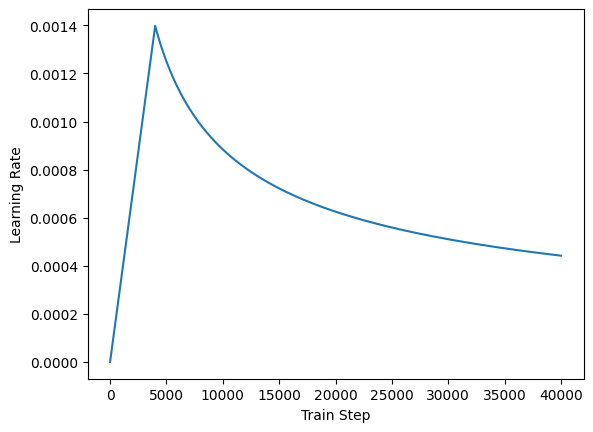

In [44]:
plt.plot(learning_rate(tf.range(40000, dtype=tf.float32)))
plt.ylabel('Learning Rate')
plt.xlabel('Train Step')

### 9b - Train the model

With all the components ready, configure the training procedure using `model.compile`, and then run it with `model.fit`.

Since the target sequences are padded, it is important to apply a padding mask when calculating the loss and the accuracy of the model. Use the `masked_loss` and `masked_accuracy` already defined for you in `utils.py` (the cross-entropy loss function is used for the loss).

Note: This takes about an hour to train in Colab.

In [45]:
#transformer.build(input_shape=[(None, MAX_TOKENS), (None, MAX_TOKENS)])
#transformer.summary()
transformer.compile(
    loss=masked_loss,
    optimizer=optimizer,
    metrics=[masked_accuracy],
    run_eagerly=True)

In [ ]:
transformer.fit(train_batches,
                epochs=1,
                validation_data=val_batches)
transformer.save_weights('my_transformer_weights.weights.h5')

305/810 ━━━━━━━━━━━━━━━━━━━━ 2:23:50 17s/step - loss: 8.5088 - masked_accuracy: 0.0472

In [46]:
# If you want to load presaved weights uncomment the line below
#transformer.load_weights('transformer_weights.weights.h5')

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 345 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 10 - Create the translator

You can now put together the tokenizers and the trained Transformer to create the translator. The following steps are used for inference:

* Encode the input sentence using the Portuguese tokenizer (`tokenizer_pt`). This is the encoder input.
* The decoder input is initialized to the `[START]` token.
* Calculate the padding masks and the look ahead masks.
* The `decoder` outputs the predictions by looking at the `encoder output` and its own output (self-attention). Note that teacher forcing is used only during training. During inference the decoder uses its last prediction to obtain the new one.
* Concatenate the predicted token to the decoder input and pass it to the decoder.
* In this approach, the decoder predicts the next token based on the previous tokens it predicted (remember that teacher-forcing is a technique used only during training).

Note: The model is optimized for _efficient training_ and makes a next-token prediction for each token in the output simultaneously. This is redundant during inference as only the last prediction is used. This model can be made more efficient for inference if you only calculate the last prediction when running in inference mode (`training=False`).

Define the `Translator` class by subclassing `tf.Module`:

In [48]:
class Translator(tf.Module):
  def __init__(self, tokenizer_en, tokenizer_pt, transformer):
    self.tokenizer_en = tokenizer_en
    self.tokenizer_pt = tokenizer_pt
    self.transformer = transformer

  def __call__(self, sentence, max_length=MAX_TOKENS):
    # The input sentence is Portuguese, hence adding the `[START]` and `[END]` tokens.
    assert isinstance(sentence, tf.Tensor)
    if len(sentence.shape) == 0:
      sentence = sentence[tf.newaxis]

    sentence = self.tokenizer_pt.tokenize(sentence).to_tensor()

    encoder_input = sentence

    # As the output language is English, initialize the output with the
    # English `[START]` token.
    start_end = self.tokenizer_en.tokenize([''])[0]
    start = start_end[0][tf.newaxis]
    end = start_end[1][tf.newaxis]

    # `tf.TensorArray` is required here (instead of a Python list), so that the
    # dynamic-loop can be traced by `tf.function`.
    output_array = tf.TensorArray(dtype=tf.int64, size=0, dynamic_size=True)
    output_array = output_array.write(0, start)

    for i in tf.range(max_length):
      output = tf.transpose(output_array.stack())

      # pass encoder_input and output to the transformer model, use training=False
      # while during training you used teacher forcing, here the decoder obtain
      # a new prediction using the output of the encoder and its previous prediction
      predictions = self.transformer([encoder_input, output], training=False)

      # Select the last token from the `seq_len` dimension.
      predictions = predictions[:, -1:, :]  # Shape `(batch_size, 1, vocab_size)`.

      predicted_id = tf.argmax(predictions, axis=-1)

      # Concatenate the `predicted_id` to the output which is given to the
      # decoder as its input.
      output_array = output_array.write(i+1, predicted_id[0])

      if predicted_id == end:
        break

    output = tf.transpose(output_array.stack())
    # The output shape is `(1, tokens)`.
    text = tokenizer_en.detokenize(output)[0]  # Shape: `()`.

    tokens = tokenizer_en.lookup(output)[0]

    # `tf.function` prevents us from using the attention_weights that were
    # calculated on the last iteration of the loop.
    # So, recalculate them outside the loop.
    self.transformer([encoder_input, output[:,:-1]], training=False)
    attention_weights = self.transformer.decoder.last_attn_scores

    return text, tokens, attention_weights

Create an instance of this `Translator` class, and try it out a few times:

In [49]:
translator = Translator(tokenizer_en, tokenizer_pt, transformer)

In [50]:
def print_translation(sentence, tokens, ground_truth):
  print(f'{"Input:":15s}: {sentence}')
  print(f'{"Prediction":15s}: {tokens.numpy().decode("utf-8")}')
  print(f'{"Ground truth":15s}: {ground_truth}')

Example 1:

In [51]:
sentence = 'este é um problema que temos que resolver.'
ground_truth = 'this is a problem we have to solve .'

translated_text, translated_tokens, attention_weights = translator(
    tf.constant(sentence))
print_translation(sentence, translated_text, ground_truth)

/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Input:         : este é um problema que temos que resolver.
Prediction     : this is a problem that we have to solve .
Ground truth   : this is a problem we have to solve .


Example 2:

In [52]:
sentence = 'os meus vizinhos ouviram sobre esta ideia.'
ground_truth = 'and my neighboring homes heard about this idea .'

translated_text, translated_tokens, attention_weights = translator(
    tf.constant(sentence))
print_translation(sentence, translated_text, ground_truth)

Input:         : os meus vizinhos ouviram sobre esta ideia.
Prediction     : my neighbors heard about this idea .
Ground truth   : and my neighboring homes heard about this idea .


Example 3:

In [53]:
sentence = 'vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram.'
ground_truth = "so i'll just share with you some stories very quickly of some magical things that have happened."

translated_text, translated_tokens, attention_weights = translator(
    tf.constant(sentence))
print_translation(sentence, translated_text, ground_truth)

Input:         : vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram.
Prediction     : so i ' ll go very quickly share with you some very magic stories that happened .
Ground truth   : so i'll just share with you some stories very quickly of some magical things that have happened.


### 10a - Save the translator

Let's save the trained translator. To do that, we create a class called `ExportTranslator` by subclassing the `tf.Module` subclass. The `tf.function` instruction above the `__call__` method make the function only return the output sentence: thanks to the [non-strict execution](https://tensorflow.org/guide/intro_to_graphs) in `tf.function` any unnecessary values are never computed.

In [54]:
class ExportTranslator(tf.Module):
  def __init__(self, translator):
    self.translator = translator

  @tf.function(input_signature=[tf.TensorSpec(shape=[], dtype=tf.string)])
  def __call__(self, sentence):
    (result,
     tokens,
     attention_weights) = self.translator(sentence, max_length=MAX_TOKENS)

    return result

In [55]:
translator_trained = ExportTranslator(translator)

If you want to use the pre-trained translator uncomment and execute the cell below.

In [ ]:
# translator = tf.saved_model.load('translator_trained')

## 11 - Create attention plots

The `Translator` class you created in the previous section returns a dictionary of attention heatmaps you can use to visualize the internal working of the model.

For example:

In [56]:
sentence = 'este é o primeiro livro que eu fiz.'
ground_truth = "this is the first book i've ever done."

translated_text, translated_tokens, attention_weights = translator(
    tf.constant(sentence))
print_translation(sentence, translated_text, ground_truth)

Input:         : este é o primeiro livro que eu fiz.
Prediction     : this is the first book that i did .
Ground truth   : this is the first book i've ever done.


Create a function that plots the attention when a token is generated:

In [57]:
def plot_attention_head(in_tokens, translated_tokens, attention):
  # The model didn't generate `<START>` in the output. Skip it.
  translated_tokens = translated_tokens[1:]

  ax = plt.gca()
  ax.matshow(attention)
  ax.set_xticks(range(len(in_tokens)))
  ax.set_yticks(range(len(translated_tokens)))

  labels = [label.decode('utf-8') for label in in_tokens.numpy()]
  ax.set_xticklabels(
      labels, rotation=90)

  labels = [label.decode('utf-8') for label in translated_tokens.numpy()]
  ax.set_yticklabels(labels)

In [58]:
head = 0
# Shape: `(batch=1, num_heads, seq_len_q, seq_len_k)`.
attention_heads = tf.squeeze(attention_weights, 0)
attention = attention_heads[head]
attention.shape

TensorShape([10, 11])

These are the input (Portuguese) tokens:

In [59]:
in_tokens = tf.convert_to_tensor([sentence])
in_tokens = tokenizer_pt.tokenize(in_tokens).to_tensor()
in_tokens = tokenizer_pt.lookup(in_tokens)[0]
in_tokens

<tf.Tensor: shape=(11,), dtype=string, numpy=
array([b'[START]', b'este', b'e', b'o', b'primeiro', b'livro', b'que',
       b'eu', b'fiz', b'.', b'[END]'], dtype=object)>

And these are the output (English translation) tokens:

In [60]:
translated_tokens

<tf.Tensor: shape=(11,), dtype=string, numpy=
array([b'[START]', b'this', b'is', b'the', b'first', b'book', b'that',
       b'i', b'did', b'.', b'[END]'], dtype=object)>

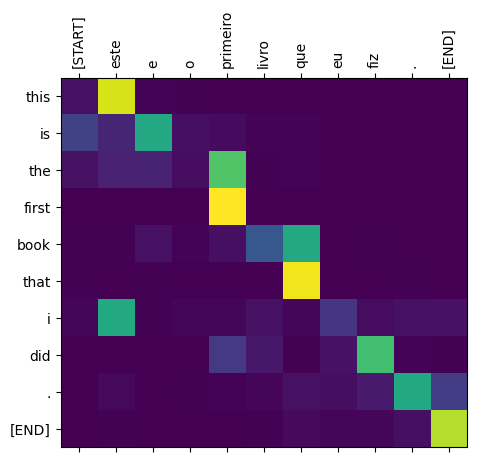

In [61]:
plot_attention_head(in_tokens, translated_tokens, attention)

In [62]:
def plot_attention_weights(sentence, translated_tokens, attention_heads):
  in_tokens = tf.convert_to_tensor([sentence])
  in_tokens = tokenizer_pt.tokenize(in_tokens).to_tensor()
  in_tokens = tokenizer_pt.lookup(in_tokens)[0]

  fig = plt.figure(figsize=(16, 8))

  for h, head in enumerate(attention_heads):
    ax = fig.add_subplot(2, 4, h+1)

    plot_attention_head(in_tokens, translated_tokens, head)

    ax.set_xlabel(f'Head {h+1}')

  plt.tight_layout()
  plt.show()

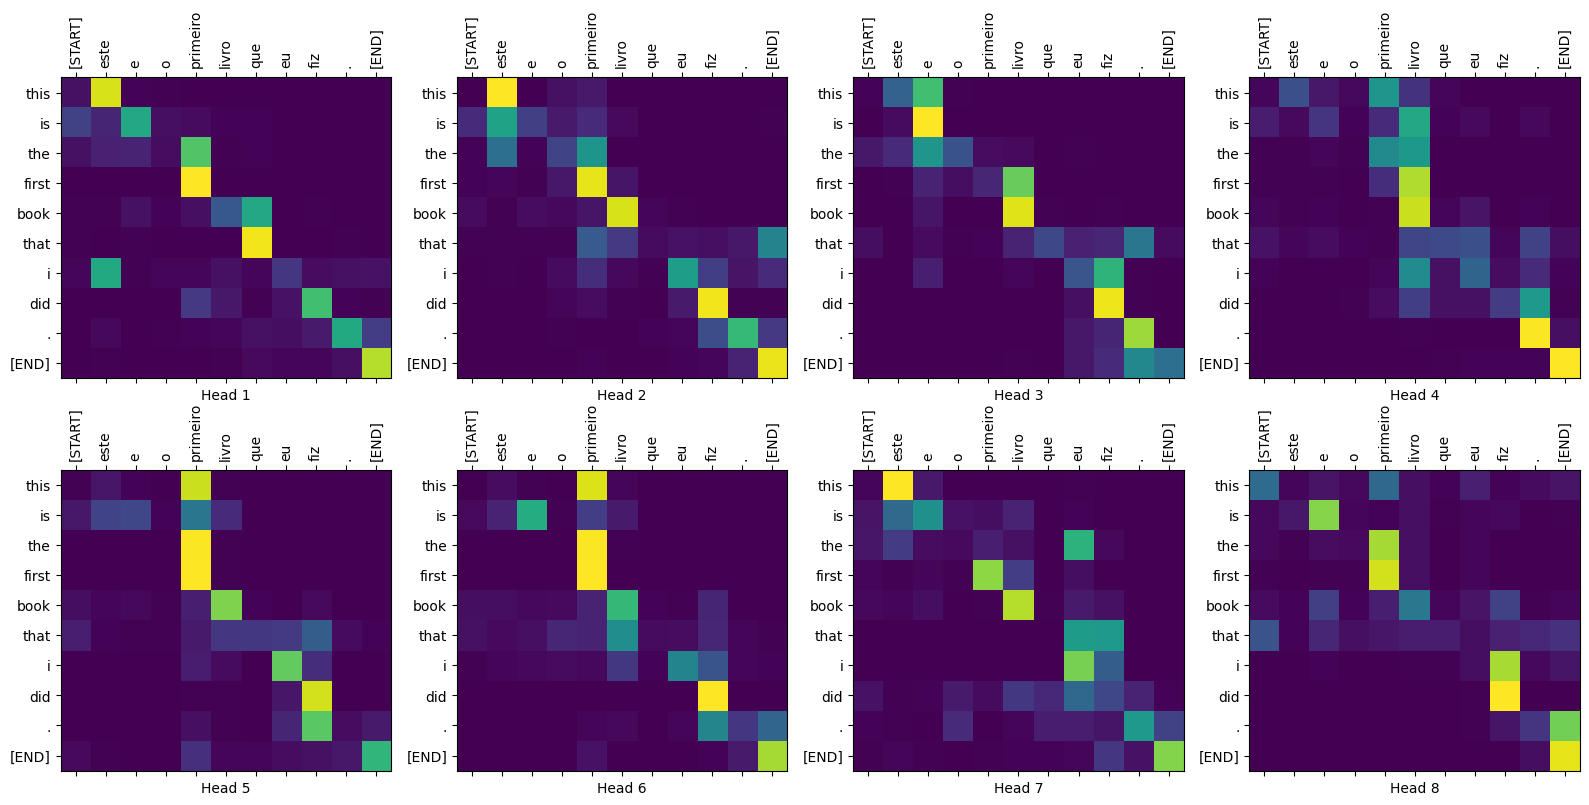

In [63]:
plot_attention_weights(sentence,
                       translated_tokens,
                       attention_weights[0])

The model can handle unfamiliar words. Neither `'triceratops'` nor `'encyclopédia'` are in the input dataset, and the model attempts to transliterate them even without a shared vocabulary. For example:

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'query' (of type EinsumDense) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'key' (of type EinsumDense) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'value' (of type EinsumDense) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/ke

Input:         : Eu li sobre triceratops na enciclopédia.
Prediction     : i read about throlled on the esloped .
Ground truth   : I read about triceratops in the encyclopedia.


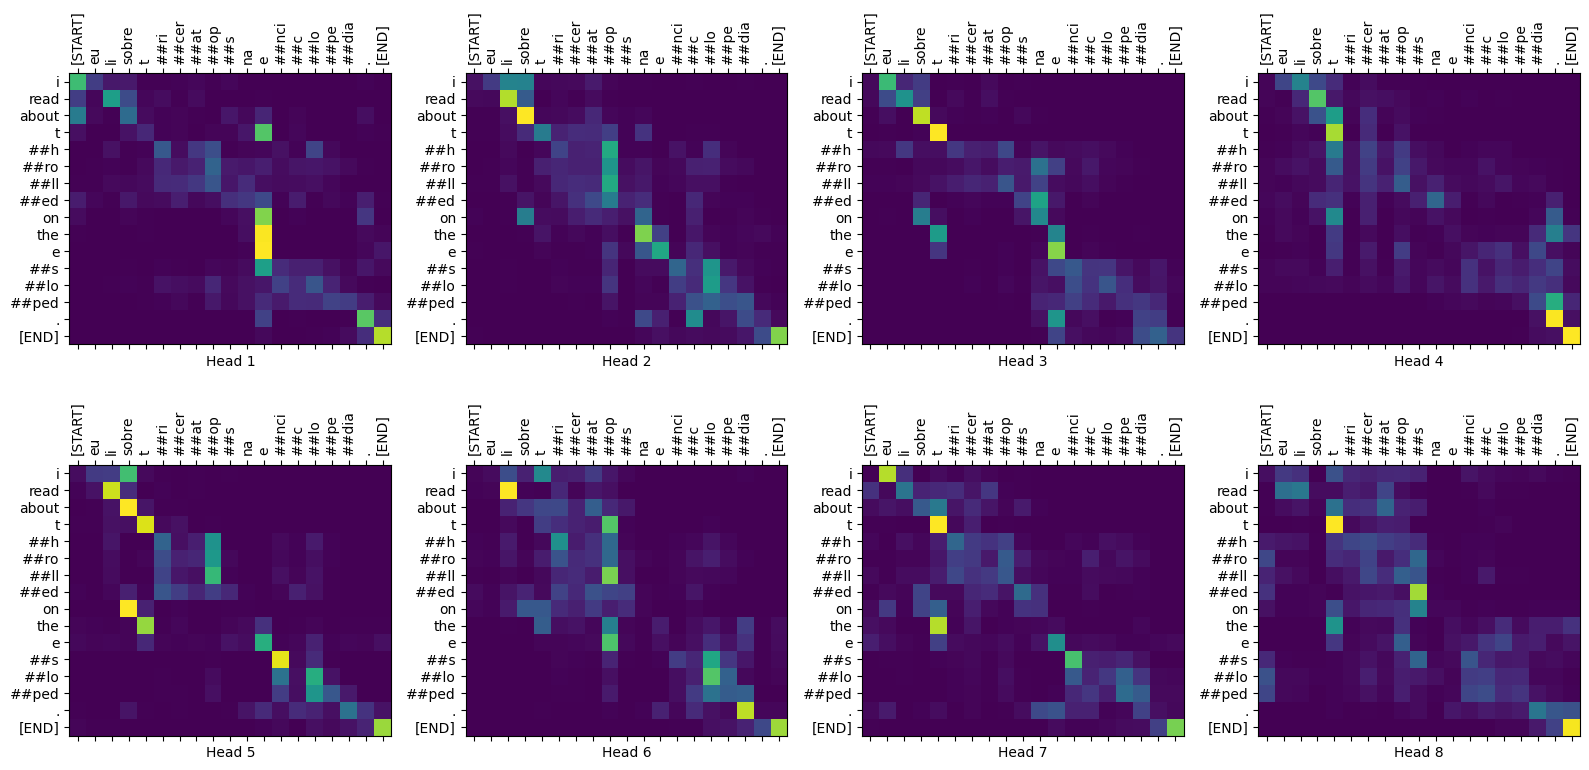

In [64]:
sentence = 'Eu li sobre triceratops na enciclopédia.'
ground_truth = 'I read about triceratops in the encyclopedia.'

translated_text, translated_tokens, attention_weights = translator(
    tf.constant(sentence))
print_translation(sentence, translated_text, ground_truth)

plot_attention_weights(sentence, translated_tokens, attention_weights[0])

## Conclusion

The downsides of this architecture are:

- For a time-series, the output for a time-step is calculated from the *entire history* instead of only the inputs and current hidden-state. This _may_ be less efficient than seq-to-seq.
- If the input has a temporal/spatial relationship, like text or images, some positional encoding must be added or the model will effectively see a bag of words.

There are a wide variety of Transformer-based models, many of which improve upon the 2017 version of the original Transformer with encoder-decoder, encoder-only and decoder-only architectures.

Some of these models are covered in the following research publications:

* ["Efficient Transformers: a survey"](https://arxiv.org/abs/2009.06732) (Tay et al., 2022)
* ["Formal algorithms for Transformers"](https://arxiv.org/abs/2207.09238) (Phuong and Hutter, 2022).
* [T5 ("Exploring the limits of transfer learning with a unified text-to-text Transformer")](https://arxiv.org/abs/1910.10683) (Raffel et al., 2019)

You can learn more about other models in the following Google blog posts: [PaLM](https://ai.googleblog.com/2022/04/pathways-language-model-palm-scaling-to.html), [LaMDA](https://ai.googleblog.com/2022/01/lamda-towards-safe-grounded-and-high.html), [MUM](https://blog.google/products/search/introducing-mum/), [Reformer](https://ai.googleblog.com/2020/01/reformer-efficient-transformer.html), [BERT](https://ai.googleblog.com/2018/11/open-sourcing-bert-state-of-art-pre.html)
